In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [ ]:
df = pd.read_csv("/content/BreastCancer.csv")

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
# Remove rows with missing survival information
df = df.dropna(subset=[
    "Overall Survival (Months)",
    "Overall Survival Status"
])

# Convert survival months to numeric
df["Overall Survival (Months)"] = pd.to_numeric(
    df["Overall Survival (Months)"],
    errors="coerce"
)

# Exclude censored patients with less than 60 months follow-up
df = df[
    ~(
        (df["Overall Survival Status"] == "0:LIVING") &
        (df["Overall Survival (Months)"] < 60)
    )
]

# Create binary target
df["Survival_Label"] = np.where(
    (df["Overall Survival Status"] == "0:LIVING") &
    (df["Overall Survival (Months)"] >= 60),
    1,
    0
)

In [ ]:
print(df["Survival_Label"].value_counts())

print(df["Survival_Label"].value_counts(normalize=True))

Survival_Label
0    1144
1     773
Name: count, dtype: int64
Survival_Label
0    0.596766
1    0.403234
Name: proportion, dtype: float64


In [ ]:
drop_columns = [

    "Overall Survival (Months)",

    "Overall Survival Status",

    "Patient's Vital Status",

    "Study ID",

    "Patient ID",

    "Sample ID"

]

X = df.drop(columns=drop_columns + ["Survival_Label"])

y = df["Survival_Label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [ ]:
X_test_original = X_test.copy()

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([

    ("num", numeric_transformer, numeric_features),

    ("cat", categorical_transformer, categorical_features)

])

Logistic Regression


In [ ]:
pipe = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(random_state=42))

])

In [ ]:
param_grid = {

    "classifier__C":[0.01,0.1,1,10,100],

    "classifier__penalty":["l2"],

    "classifier__solver":["lbfgs"],

    "classifier__max_iter":[1000]

}

grid = GridSearchCV(

    pipe,

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade',
       'Lymph nodes examined positive', 'Mutation Count',
       'Nottingham prognostic index', 'Relapse Free Status (Months)',...
       'Primary Tumor Laterality', 'Oncotree Code', 'PR Status',
       'Radio Therapy', 'Relapse Free Status', 'Sample Type', 'Sex',
       '3-Gene classifier subtype'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__max_iter': [1000],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs']},
             scoring='accuracy')

In [ ]:
# Cross Validation Accuracy
cv_scores = cross_val_score(
    grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

In [ ]:
print(grid.best_params_)

{'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


In [ ]:
best_model = grid.best_estimator_

# Training Predictions

train_pred = best_model.predict(X_train)
train_prob = best_model.predict_proba(X_train)[:,1]

# Testing Predictions

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
print("========== TRAINING ==========")

print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision :", precision_score(y_train, train_pred))
print("Recall :", recall_score(y_train, train_pred))
print("F1 :", f1_score(y_train, train_pred))
print("ROC AUC :", roc_auc_score(y_train, train_prob))

print("\n========== TESTING ==========")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_prob))

========== TRAINING ==========
Accuracy : 0.8264840182648402
Precision : 0.7913907284768212
Recall : 0.7734627831715211
F1 : 0.7823240589198036
ROC AUC : 0.8989247882292606

========== TESTING ==========
Accuracy : 0.8125
Precision : 0.7712418300653595
Recall : 0.7612903225806451
F1 : 0.7662337662337663
ROC AUC : 0.8886603747006621


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       229
           1       0.77      0.76      0.77       155

    accuracy                           0.81       384
   macro avg       0.81      0.80      0.80       384
weighted avg       0.81      0.81      0.81       384



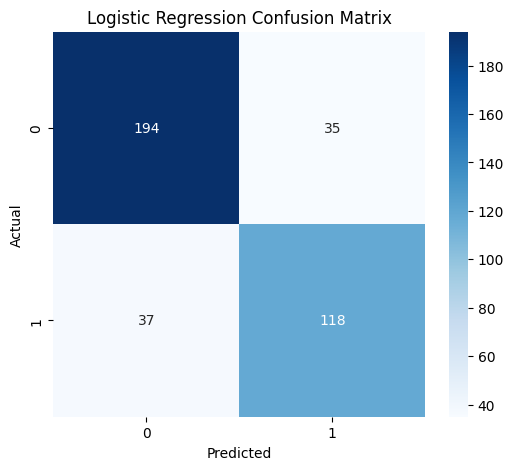

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

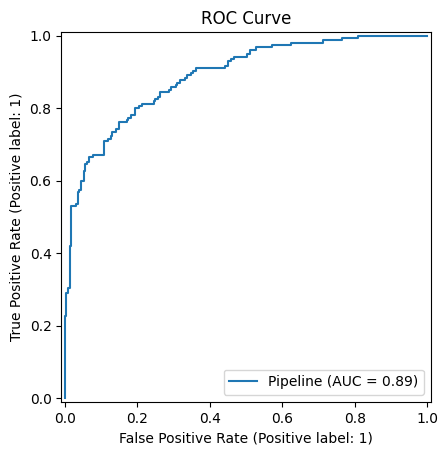

In [ ]:
RocCurveDisplay.from_estimator(

    best_model,

    X_test,

    y_test

)

plt.title("ROC Curve")

plt.show()

Feature Importance

In [ ]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients
coefficients = best_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Absolute
82,cat__Relapse Free Status_1:Recurred,-1.414211,1.414211
81,cat__Relapse Free Status_0:Not Recurred,1.325841,1.325841
0,num__Age at Diagnosis,-1.304242,1.304242
21,cat__Cancer Type Detailed_Metaplastic Breast C...,-0.955333,0.955333
47,cat__Tumor Other Histologic Subtype_Metaplastic,-0.955333,0.955333
74,cat__Oncotree Code_MBC,-0.955333,0.955333
64,cat__Integrative Cluster_7,-0.746590,0.746590
41,cat__HER2 status measured by SNP6_UNDEF,0.606959,0.606959
6,num__Relapse Free Status (Months),0.593964,0.593964
57,cat__Integrative Cluster_10,0.585341,0.585341


Ploting Feature Importance

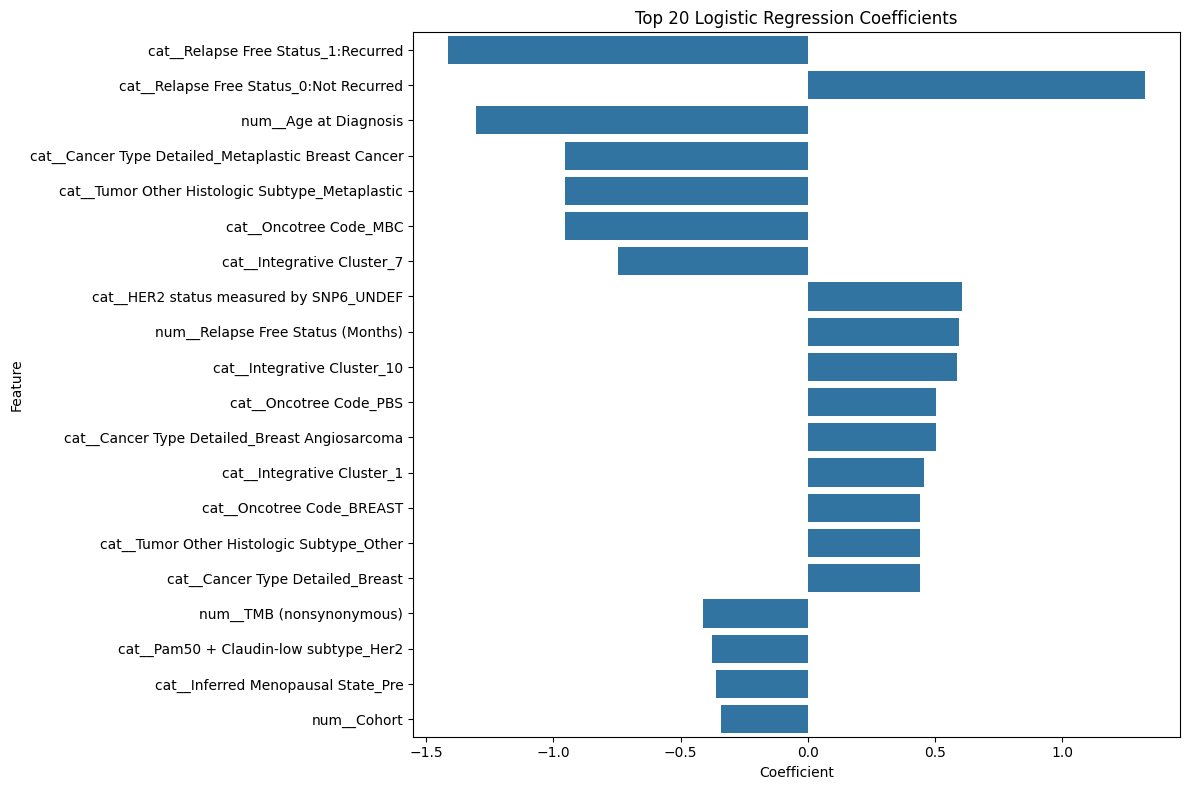

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=coef_df.head(20),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 20 Logistic Regression Coefficients")

plt.xlabel("Coefficient")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

Saving Performance Metrics

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results_lr = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Training":[

        accuracy_score(y_train,train_pred),

        precision_score(y_train,train_pred),

        recall_score(y_train,train_pred),

        f1_score(y_train,train_pred),

        roc_auc_score(y_train,train_prob)

    ],

    "Cross Validation":[

        cv_scores.mean(),

        None,

        None,

        None,

        None

    ],

    "Testing":[

        accuracy_score(y_test,y_pred),

        precision_score(y_test,y_pred),

        recall_score(y_test,y_pred),

        f1_score(y_test,y_pred),

        roc_auc_score(y_test,y_prob)

    ]

})

results_lr

,Metric,Training,Cross Validation,Testing
0,Accuracy,0.826484,0.812804,0.812500
1,Precision,0.791391,NaN,0.771242
2,Recall,0.773463,NaN,0.761290
3,F1 Score,0.782324,NaN,0.766234
4,ROC AUC,0.898925,NaN,0.888660


In [ ]:
print("Cross Validation Accuracy")

print("Mean :",cv_scores.mean())

print("Std :",cv_scores.std())

Cross Validation Accuracy
Mean : 0.8128036448021119
Std : 0.021125252523632235


Saving Results

In [ ]:
results_lr.to_csv(
    "LogisticRegression_Performance.csv",
    index=False
)

Saving Fearure Importance

In [ ]:
coef_df.to_csv(
    "LogisticRegression_Coefficients.csv",
    index=False
)

Fairness Evaluation

In [ ]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.4 MB/s eta 0:00:00


In [ ]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference,
    true_positive_rate,
    false_positive_rate
)

In [ ]:
fairness_df = X_test_original.copy()

fairness_df["True"] = y_test.values

fairness_df["Prediction"] = y_pred

fairness_df["Age_Group"] = pd.cut(

    fairness_df["Age at Diagnosis"],

    bins=[0,40,65,120],

    labels=[
        "Young (<40)",
        "Middle (40-65)",
        "Older (>65)"
    ]

)

In [ ]:
dp = demographic_parity_difference(

    y_true=fairness_df["True"],

    y_pred=fairness_df["Prediction"],

    sensitive_features=fairness_df["Age_Group"]

)

print("Demographic Parity Difference:", dp)

Demographic Parity Difference: 0.38002782314159556


In [ ]:
eo = equalized_odds_difference(

    y_true=fairness_df["True"],

    y_pred=fairness_df["Prediction"],

    sensitive_features=fairness_df["Age_Group"]

)

print("Equalized Odds Difference:", eo)

Equalized Odds Difference: 0.36257309941520466


In [ ]:
metrics = MetricFrame(

    metrics={
        "Selection Rate": selection_rate,
        "TPR": true_positive_rate,
        "FPR": false_positive_rate
    },

    y_true=fairness_df["True"],

    y_pred=fairness_df["Prediction"],

    sensitive_features=fairness_df["Age_Group"]

)

metrics.by_group

,Selection Rate,TPR,FPR
Age_Group,,,
Middle (40-65),0.565657,0.833333,0.244444
Older (>65),0.185629,0.526316,0.085271
Young (<40),0.526316,0.888889,0.200000


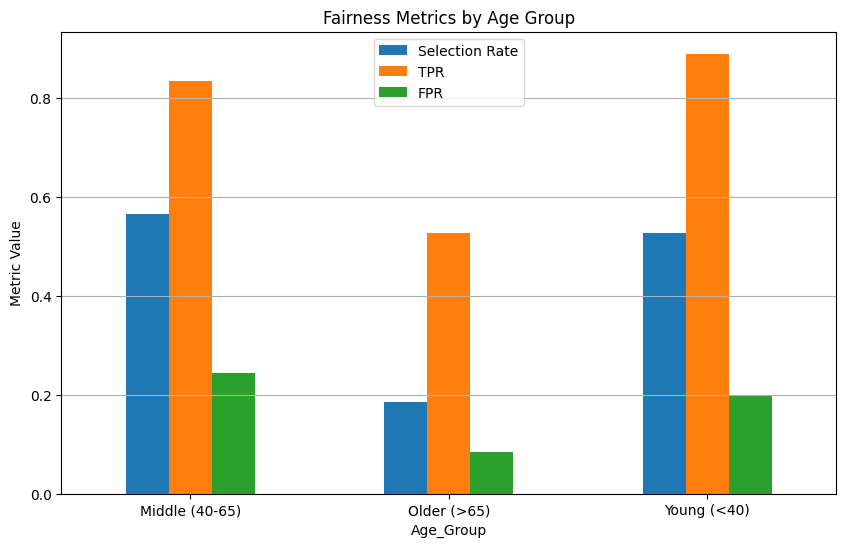

In [ ]:
metrics.by_group.plot.bar(figsize=(10,6))

plt.title("Fairness Metrics by Age Group")

plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Create the Random Forest Pipeline

In [ ]:
rf_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(random_state=42))

])

Hyperparameter Grid

In [ ]:
rf_param_grid = {

    "classifier__n_estimators": [100, 200, 300],

    "classifier__max_depth": [None, 10, 20, 30],

    "classifier__min_samples_split": [2, 5, 10],

    "classifier__min_samples_leaf": [1, 2, 4],

    "classifier__max_features": ["sqrt", "log2"]

}

Grid Search

In [ ]:
rf_grid = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=rf_param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade',
       'Lymph nodes examined positive', 'Mutation Count',
       'Nottingham prognostic index', 'Relapse Free Status (Months)',...
       '3-Gene classifier subtype'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20, 30],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [ ]:
rf_cv_scores = cross_val_score(

    rf_grid.best_estimator_,

    X_train,

    y_train,

    cv=5,

    scoring="accuracy"

)

Best Parameters

In [ ]:
print("Best Parameters:")

print(rf_grid.best_params_)

Best Parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}


Best Model

In [ ]:
rf_model = rf_grid.best_estimator_

In [ ]:
# Training

rf_train_pred = rf_model.predict(X_train)

rf_train_prob = rf_model.predict_proba(X_train)[:,1]

# Testing

rf_test_pred = rf_model.predict(X_test)

rf_test_prob = rf_model.predict_proba(X_test)[:,1]

Prediction

In [ ]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

Performance Metrics

In [ ]:
print("========== TRAINING ==========")

print("Accuracy :", accuracy_score(y_train, rf_train_pred))
print("Precision :", precision_score(y_train, rf_train_pred))
print("Recall :", recall_score(y_train, rf_train_pred))
print("F1 Score :", f1_score(y_train, rf_train_pred))
print("ROC AUC :", roc_auc_score(y_train, rf_train_prob))

print("\n========== TESTING ==========")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC :", roc_auc_score(y_test, rf_prob))

========== TRAINING ==========
Accuracy : 0.9001956947162426
Precision : 0.8868552412645591
Recall : 0.8624595469255664
F1 Score : 0.874487284659557
ROC AUC : 0.9743735299839072

========== TESTING ==========
Accuracy : 0.8411458333333334
Precision : 0.821917808219178
Recall : 0.7741935483870968
F1 Score : 0.7973421926910299
ROC AUC : 0.909170305676856


Classification Report

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       229
           1       0.82      0.77      0.80       155

    accuracy                           0.84       384
   macro avg       0.84      0.83      0.83       384
weighted avg       0.84      0.84      0.84       384



Confusion matrix

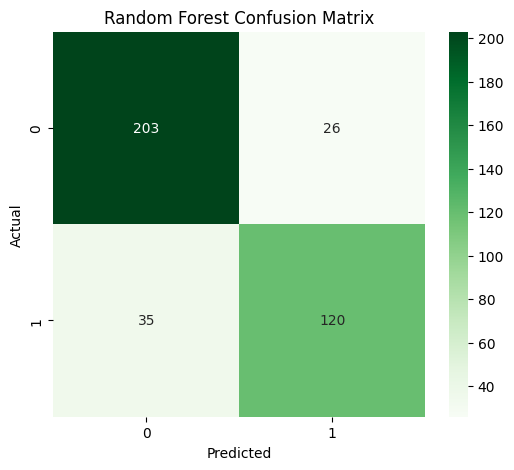

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

ROC Curve

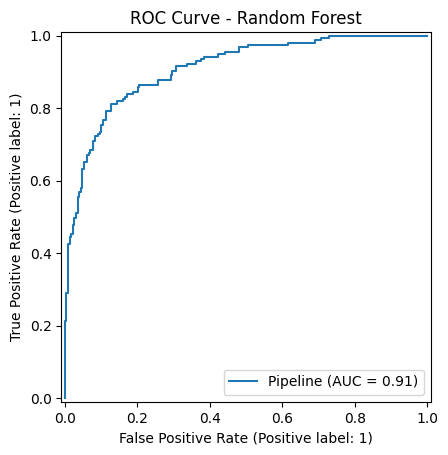

In [ ]:
RocCurveDisplay.from_estimator(

    rf_model,

    X_test,

    y_test

)

plt.title("ROC Curve - Random Forest")

plt.show()

Feature Importance

In [ ]:
feature_names = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = rf_model.named_steps[
    "classifier"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

importance_df.head(20)

,Feature,Importance
6,num__Relapse Free Status (Months),0.162169
81,cat__Relapse Free Status_0:Not Recurred,0.137318
82,cat__Relapse Free Status_1:Recurred,0.133984
0,num__Age at Diagnosis,0.132745
5,num__Nottingham prognostic index,0.040205
9,num__Tumor Size,0.035263
1,num__Cohort,0.026489
3,num__Lymph nodes examined positive,0.020322
8,num__TMB (nonsynonymous),0.020064
4,num__Mutation Count,0.018696


Plot Feature Importance

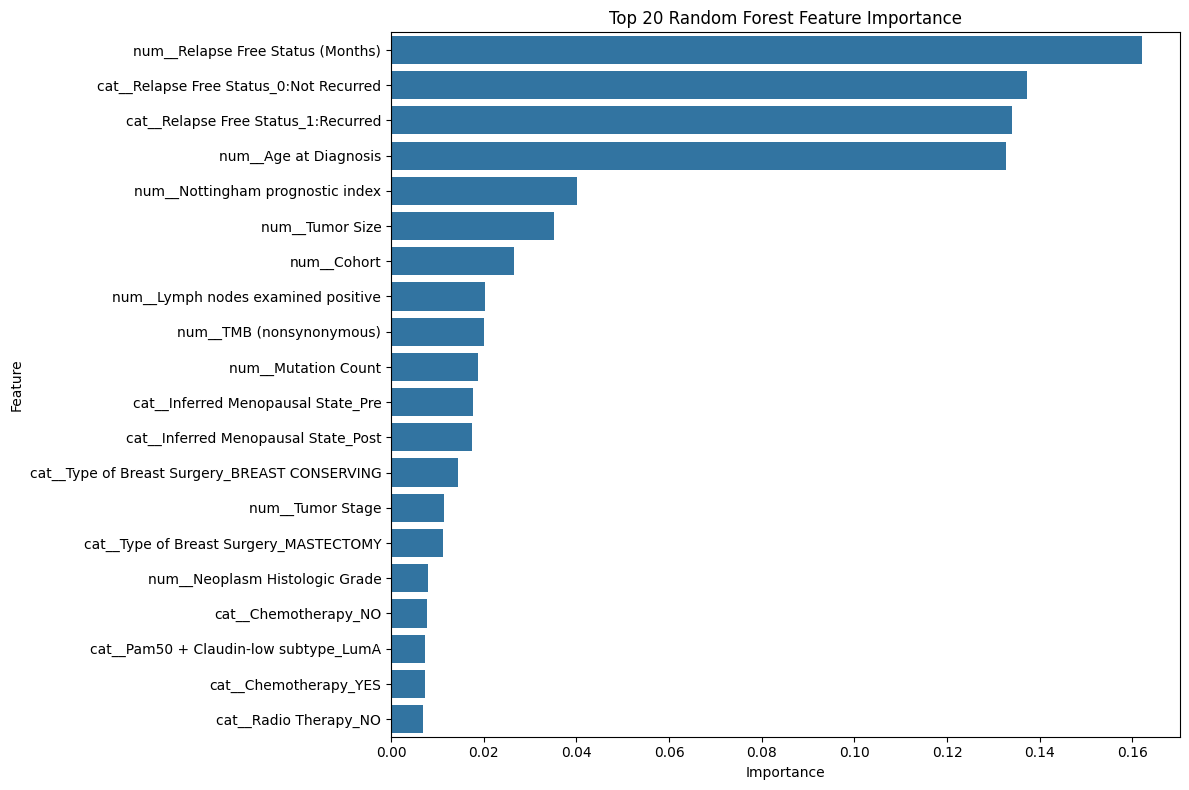

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=importance_df.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Random Forest Feature Importance")

plt.tight_layout()

plt.show()

Save results

In [ ]:
results_rf = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Training":[

        accuracy_score(y_train,rf_train_pred),

        precision_score(y_train,rf_train_pred),

        recall_score(y_train,rf_train_pred),

        f1_score(y_train,rf_train_pred),

        roc_auc_score(y_train,rf_train_prob)

    ],

    "Cross Validation":[

        rf_cv_scores.mean(),

        None,

        None,

        None,

        None

    ],

    "Testing":[

        accuracy_score(y_test,rf_test_pred),

        precision_score(y_test,rf_test_pred),

        recall_score(y_test,rf_test_pred),

        f1_score(y_test,rf_test_pred),

        roc_auc_score(y_test,rf_test_prob)

    ]

})

results_rf

,Metric,Training,Cross Validation,Testing
0,Accuracy,0.900196,0.830408,0.841146
1,Precision,0.886855,NaN,0.821918
2,Recall,0.862460,NaN,0.774194
3,F1 Score,0.874487,NaN,0.797342
4,ROC AUC,0.974374,NaN,0.909170


In [ ]:
print("Cross Validation Accuracy")

print("Mean :",rf_cv_scores.mean())

print("Std :",rf_cv_scores.std())

Cross Validation Accuracy
Mean : 0.8304081241617169
Std : 0.010546608319373886


Fairness Evaluation

In [ ]:
fairness_df = X_test_original.copy()

fairness_df["True"] = y_test.values

fairness_df["Prediction"] = rf_pred

fairness_df["Age_Group"] = pd.cut(

    fairness_df["Age at Diagnosis"],

    bins=[0,40,65,120],

    labels=[

        "Young (<40)",

        "Middle (40-65)",

        "Older (>65)"

    ]

)

Demographic Parity Difference

In [ ]:
dp_rf = demographic_parity_difference(

    y_true=fairness_df["True"],

    y_pred=fairness_df["Prediction"],

    sensitive_features=fairness_df["Age_Group"]

)

print("Demographic Parity Difference:", dp_rf)

Demographic Parity Difference: 0.42100647190467555


Equalized Odds Difference

In [ ]:
eo_rf = equalized_odds_difference(

    y_true=fairness_df["True"],

    y_pred=fairness_df["Prediction"],

    sensitive_features=fairness_df["Age_Group"]

)

print("Equalized Odds Difference:", eo_rf)

Equalized Odds Difference: 0.4152046783625731


Group-wise Fairness Metrics

In [ ]:
rf_metrics = MetricFrame(

    metrics={

        "Selection Rate": selection_rate,

        "TPR": true_positive_rate,

        "FPR": false_positive_rate

    },

    y_true=fairness_df["True"],

    y_pred=fairness_df["Prediction"],

    sensitive_features=fairness_df["Age_Group"]

)

print(rf_metrics.by_group)

                Selection Rate       TPR       FPR
Age_Group                                         
Middle (40-65)        0.570707  0.870370  0.211111
Older (>65)           0.149701  0.473684  0.054264
Young (<40)           0.421053  0.888889  0.000000


Fairness plot

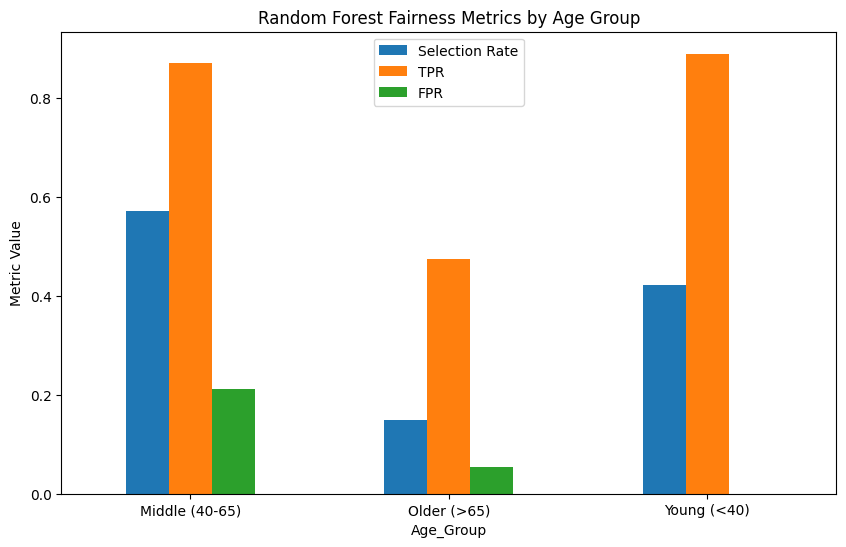

In [ ]:
rf_metrics.by_group.plot.bar(figsize=(10,6))

plt.title("Random Forest Fairness Metrics by Age Group")

plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.show()

XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

In [ ]:
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [ ]:
from sklearn.pipeline import Pipeline

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

In [ ]:
from sklearn.model_selection import GridSearchCV

xgb_grid = GridSearchCV(
    xgb_pipe,
    param_grid=xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:40:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade',
       'Lymph nodes examined positive', 'Mutation Count',
       'Nottingham prognostic index', 'Relapse Free Status (Months)',...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:")
print(xgb_grid.best_params_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}


In [ ]:
from sklearn.model_selection import cross_val_score

xgb_cv_scores = cross_val_score(
    xgb_grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Accuracy")

print("Mean :", xgb_cv_scores.mean())

print("Std :", xgb_cv_scores.std())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:40:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:40:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:40:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:40:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Cross Validation Accuracy
Mean : 0.8323625215558537
Std : 0.0233089805661965


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:40:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
xgb_model = xgb_grid.best_estimator_

In [ ]:
# Training

xgb_train_pred = xgb_model.predict(X_train)
xgb_train_prob = xgb_model.predict_proba(X_train)[:,1]

# Testing

xgb_test_pred = xgb_model.predict(X_test)
xgb_test_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
age_groups = pd.cut(
    X_test["Age at Diagnosis"],
    bins=[0, 40, 65, 150],
    labels=["Young (<40)", "Middle (40-65)", "Older (>65)"]
)

In [ ]:
import numpy as np
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference
)
from sklearn.metrics import accuracy_score

thresholds = np.arange(0.20, 0.61, 0.05)

results = []

for threshold in thresholds:

    preds = (xgb_test_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, preds)

    dpd = demographic_parity_difference(
        y_true=y_test,
        y_pred=preds,
        sensitive_features=age_groups
    )

    eod = equalized_odds_difference(
        y_true=y_test,
        y_pred=preds,
        sensitive_features=age_groups
    )

    results.append([threshold, acc, dpd, eod])

In [ ]:
threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "DPD",
        "EOD"
    ]
)

threshold_results

,Threshold,Accuracy,DPD,EOD
0,0.20,0.765625,0.211577,0.166667
1,0.25,0.781250,0.256306,0.144444
2,0.30,0.799479,0.278957,0.311111
3,0.35,0.817708,0.322748,0.288889
4,0.40,0.841146,0.343525,0.255556
5,0.45,0.859375,0.364302,0.222222
6,0.50,0.864583,0.402105,0.283626
7,0.55,0.851562,0.390703,0.336257
8,0.60,0.848958,0.411480,0.467836


In [ ]:
# XGBoost predictions using the selected threshold
xgb_threshold = 0.45

xgb_test_pred_045 = (xgb_test_prob >= xgb_threshold).astype(int)

print("XGBoost Threshold:", xgb_threshold)
print("Number of positive predictions:", xgb_test_pred_045.sum())

XGBoost Threshold: 0.45
Number of positive predictions: 161


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

results_xgb = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Training":[

        accuracy_score(y_train,xgb_train_pred),

        precision_score(y_train,xgb_train_pred),

        recall_score(y_train,xgb_train_pred),

        f1_score(y_train,xgb_train_pred),

        roc_auc_score(y_train,xgb_train_prob)

    ],

    "Cross Validation":[

        xgb_cv_scores.mean(),

        None,

        None,

        None,

        None

    ],

    "Testing":[

        accuracy_score(y_test,xgb_test_pred_045),

        precision_score(y_test,xgb_test_pred_045),

        recall_score(y_test,xgb_test_pred_045),

        f1_score(y_test,xgb_test_pred_045),

        roc_auc_score(y_test,xgb_test_prob)

    ]

})

results_xgb

,Metric,Training,Cross Validation,Testing
0,Accuracy,0.881931,0.832363,0.859375
1,Precision,0.852989,NaN,0.813665
2,Recall,0.854369,NaN,0.845161
3,F1 Score,0.853678,NaN,0.829114
4,ROC AUC,0.958120,NaN,0.908776


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       229
           1       0.84      0.82      0.83       155

    accuracy                           0.86       384
   macro avg       0.86      0.86      0.86       384
weighted avg       0.86      0.86      0.86       384



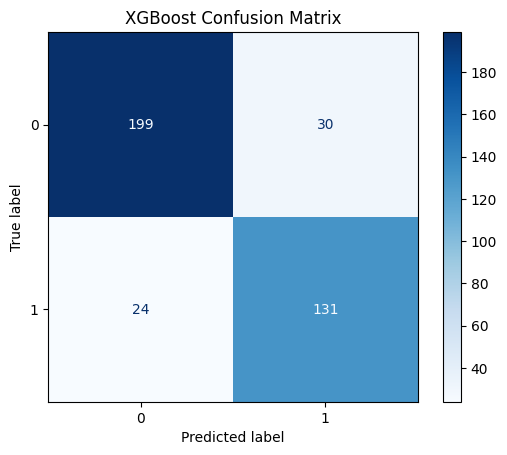

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_test_pred_045,
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.show()

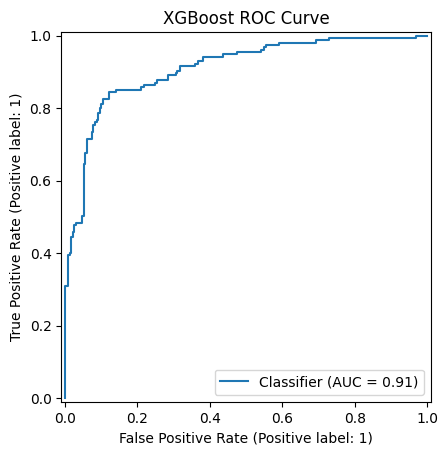

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    xgb_test_prob
)

plt.title("XGBoost ROC Curve")

plt.show()

In [ ]:
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate
)

In [ ]:
dpd = demographic_parity_difference(
    y_true=y_test,
    y_pred=xgb_test_pred_045,
    sensitive_features=age_groups
)

eod = equalized_odds_difference(
    y_true=y_test,
    y_pred=xgb_test_pred_045,
    sensitive_features=age_groups
)

print("XGBoost Fairness at Threshold = 0.45")
print("Demographic Parity Difference :", round(dpd, 3))
print("Equalized Odds Difference :", round(eod, 3))


XGBoost Fairness at Threshold = 0.45
Demographic Parity Difference : 0.364
Equalized Odds Difference : 0.222


In [ ]:
metric_frame_xgb_045 = MetricFrame(
    metrics={
        "Selection Rate": selection_rate,
        "TPR": true_positive_rate,
        "FPR": false_positive_rate
    },
    y_true=y_test,
    y_pred=xgb_test_pred_045,
    sensitive_features=age_groups
)

print("XGBoost Fairness Metrics at Threshold = 0.45")
metric_frame_xgb_045.by_group

XGBoost Fairness Metrics at Threshold = 0.45


,Selection Rate,TPR,FPR
Age at Diagnosis,,,
Middle (40-65),0.585859,0.888889,0.222222
Older (>65),0.221557,0.710526,0.077519
Young (<40),0.421053,0.888889,0.000000


In [ ]:
fairness_results = pd.DataFrame({

    "Metric":[
        "Demographic Parity Difference",
        "Equalized Odds Difference"
    ],

    "Value":[
        round(dpd,3),
        round(eod,3)
    ]

})

fairness_results

,Metric,Value
0,Demographic Parity Difference,0.364
1,Equalized Odds Difference,0.222


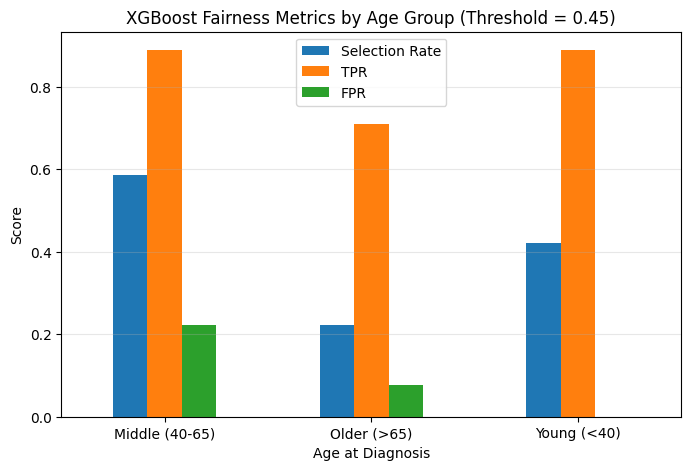

In [ ]:
import matplotlib.pyplot as plt

metric_frame_xgb_045.by_group.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("XGBoost Fairness Metrics by Age Group (Threshold = 0.45)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()